In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
(data_train, data_val, data_test), data_info = tfds.load('cats_vs_dogs',
                                               split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
                                               shuffle_files=True,
                                               as_supervised=True,
                                               with_info=True
                                               )

In [ ]:
print("Traing set size: ", len(data_train))
print("Validation set size: ", len(data_val))
print("Test set size: ", len(data_test))

In [ ]:
def normalize_img(image, label):
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [ ]:
# Training pipeline
data_train = data_train.map(normalize_img)
# data_train = data_train.cache()
data_train = data_train.shuffle(1000)
data_train = data_train.batch(32)
data_train = data_train.prefetch(tf.data.AUTOTUNE)

In [ ]:
# Validation pipeline
data_val = data_val.map(normalize_img)
data_val = data_val.batch(32)
# data_val = data_val.cache()
data_val = data_val.prefetch(tf.data.AUTOTUNE)

In [ ]:
# Testing pipeline
data_test = data_test.map(normalize_img)
data_test = data_test.batch(32)
# data_test = data_test.cache()

In [ ]:
# Flat sequential model

model = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    layers.Flatten(),
    layers.Dense(10, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [ ]:
model.compile(optimizer=keras.optimizers.Adam(0.001),
              loss = keras.losses.binary_crossentropy,
              metrics = [keras.metrics.BinaryAccuracy()])

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       491,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,474,625 (5.63 MB)

 Trainable params: 491,541 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 983,084 (3.75 MB)

In [ ]:
model.fit(data_train, epochs=10, validation_data=data_val)

In [ ]:
print(model.history.history.keys())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(model.history.history["loss"], label = "Training loss")
axes[0].plot(model.history.history["val_loss"], label = "Validation loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(model.history.history['binary_accuracy'], label = "Training Accuracy")
axes[1].plot(model.history.history['val_binary_accuracy'], label = "Validation Accuracy")
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()

In [23]:
model2 = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    layers.Conv2D(filters = 32, kernel_size=(3, 3), strides = 1, padding = 'same'),
    layers.MaxPool2D(pool_size = 2),
    layers.Flatten(),
    layers.Dense(10, activation = 'relu'),
    layers.Dense(1, activation='sigmoid')
])

In [24]:
model2.compile(optimizer = keras.optimizers.Adam(0.001),
               loss = keras.losses.binary_crossentropy,
               metrics = [keras.metrics.BinaryAccuracy()])

In [25]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │     1,310,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,311,637 (5.00 MB)

 Trainable params: 1,311,637 (5.00 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history_model2 = model2.fit(data_train, epochs = 10, validation_data=data_val)

Epoch 1/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - binary_accuracy: 0.6210 - loss: 0.6631 - val_binary_accuracy: 0.6175 - val_loss: 0.6313
Epoch 2/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - binary_accuracy: 0.6881 - loss: 0.5816 - val_binary_accuracy: 0.6212 - val_loss: 0.6681
Epoch 3/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - binary_accuracy: 0.7352 - loss: 0.5170 - val_binary_accuracy: 0.6885 - val_loss: 0.5966
Epoch 4/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - binary_accuracy: 0.7779 - loss: 0.4562 - val_binary_accuracy: 0.6728 - val_loss: 0.6435
Epoch 5/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - binary_accuracy: 0.8198 - loss: 0.3845 - val_binary_accuracy: 0.6696 - val_loss: 0.7450
Epoch 6/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - binary_accuracy: 0.8545 - loss: 0.3243 - val_binary_accuracy: 0.6759 - val_loss: 0.7961
Epoch 7/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - binary_accuracy: 0.8913 - loss: 0.2531 - val_binary_accuracy: 0.6736 - val_loss:

In [30]:
print(history_model2.history.keys())

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])


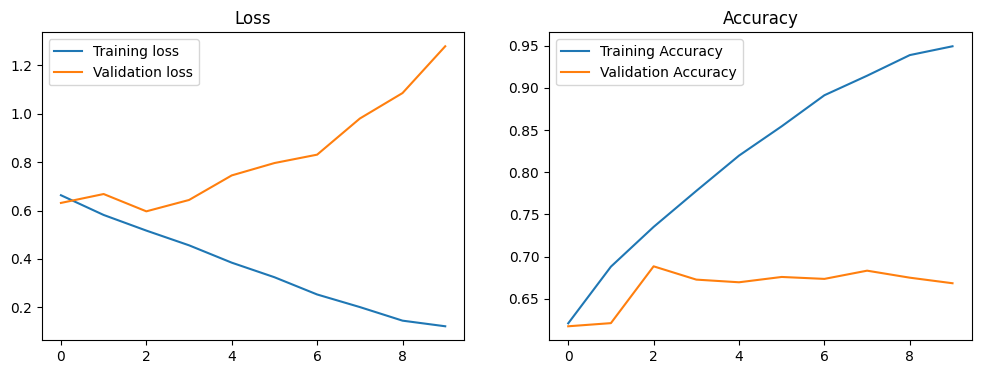

In [31]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(history_model2.history["loss"], label = "Training loss")
axes[0].plot(history_model2.history["val_loss"], label = "Validation loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_model2.history['binary_accuracy'], label = "Training Accuracy")
axes[1].plot(history_model2.history['val_binary_accuracy'], label = "Validation Accuracy")
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()

In [33]:
model3 = keras.models.Sequential([
    layers.Input(shape = (128, 128, 3)),
    layers.Conv2D(filters = 32, kernel_size = (3, 3), strides = 1, padding = 'same'),
    layers.MaxPool2D(pool_size = 2),
    layers.Conv2D(filters = 64, kernel_size = (3, 3), strides = 1, padding = 'same'),
    layers.MaxPool2D(pool_size = 2),
    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(1, activation = 'sigmoid')
])

In [34]:
model3.compile(optimizer = keras.optimizers.Adam(0.001),
               loss = keras.losses.binary_crossentropy,
               metrics = [keras.metrics.BinaryAccuracy()])

In [35]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,416,449 (32.11 MB)

 Trainable params: 8,416,449 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history_model3 = model3.fit(data_train, epochs = 20, validation_data=data_val)

Epoch 1/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - binary_accuracy: 0.6399 - loss: 0.6672 - val_binary_accuracy: 0.6991 - val_loss: 0.5746
Epoch 2/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - binary_accuracy: 0.7285 - loss: 0.5400 - val_binary_accuracy: 0.7264 - val_loss: 0.5393
Epoch 3/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - binary_accuracy: 0.7798 - loss: 0.4607 - val_binary_accuracy: 0.7424 - val_loss: 0.5330
Epoch 4/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - binary_accuracy: 0.8408 - loss: 0.3598 - val_binary_accuracy: 0.7338 - val_loss: 0.6149
Epoch 5/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - binary_accuracy: 0.8959 - loss: 0.2418 - val_binary_accuracy: 0.7315 - val_loss: 0.7850
Epoch 6/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - binary_accuracy: 0.9360 - loss: 0.1603 - val_binary_accuracy: 0.7315 - val_loss: 1.0178
Epoch 7/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - binary_accuracy: 0.9665 - loss: 0.0883 - val_binary_accuracy: 0.7390 - val_loss:

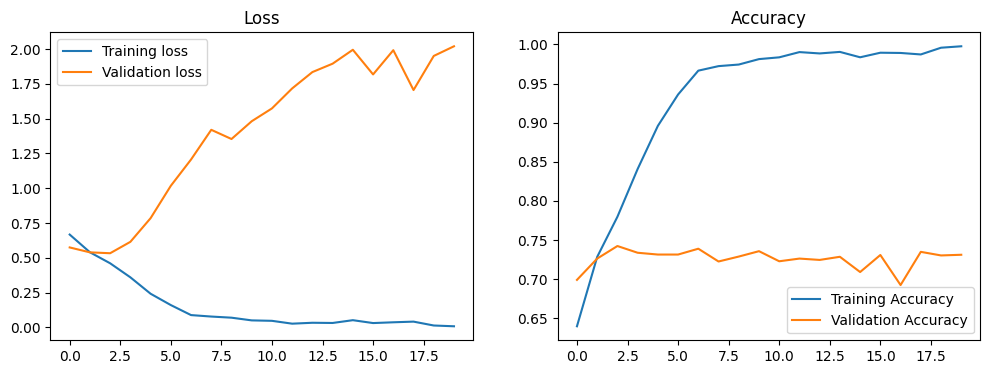

In [37]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(history_model3.history["loss"], label = "Training loss")
axes[0].plot(history_model3.history["val_loss"], label = "Validation loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_model3.history['binary_accuracy'], label = "Training Accuracy")
axes[1].plot(history_model3.history['val_binary_accuracy'], label = "Validation Accuracy")
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()